In [2]:
# Step 1: Import all libraries
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics import accuracy_score, classification_report
import matplotlib.pyplot as plt

# Step 2: Load the real Kaggle dataset
df = pd.read_csv('spam.csv', encoding='latin-1')
df = df[['v1', 'v2']]
df.columns = ['label', 'message']

print(f"Total emails loaded: {len(df)}")
print(f"Spam emails: {len(df[df['label']=='spam'])}")
print(f"Normal emails: {len(df[df['label']=='ham'])}")
print(df.head())
print("Dataset loaded successfully! ✅")

Total emails loaded: 5572
Spam emails: 747
Normal emails: 4825
  label                                            message
0   ham  Go until jurong point, crazy.. Available only ...
1   ham                      Ok lar... Joking wif u oni...
2  spam  Free entry in 2 a wkly comp to win FA Cup fina...
3   ham  U dun say so early hor... U c already then say...
4   ham  Nah I don't think he goes to usf, he lives aro...
Dataset loaded successfully! ✅


In [3]:
# Step 3: Convert labels to numbers and prepare data
df['label_num'] = df['label'].map({'ham': 0, 'spam': 1})

# Convert text to numbers
vectorizer = CountVectorizer()
X = vectorizer.fit_transform(df['message'])
y = df['label_num']

# Split data 80% training, 20% testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training messages: {X_train.shape[0]}")
print(f"Testing messages: {X_test.shape[0]}")
print("Data prepared successfully! ✅")

Training messages: 4457
Testing messages: 1115
Data prepared successfully! ✅


In [4]:
# Step 4: Train the Naive Bayes model
model = MultinomialNB()
model.fit(X_train, y_train)

# Test the model
y_pred = model.predict(X_test)

# Check accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy * 100:.2f}%")
print("\nDetailed Report:")
print(classification_report(y_test, y_pred, target_names=["Not Spam", "Spam"]))
print("Model trained successfully! ✅")

Model Accuracy: 97.85%

Detailed Report:
              precision    recall  f1-score   support

    Not Spam       0.99      0.99      0.99       965
        Spam       0.91      0.93      0.92       150

    accuracy                           0.98      1115
   macro avg       0.95      0.96      0.95      1115
weighted avg       0.98      0.98      0.98      1115

Model trained successfully! ✅


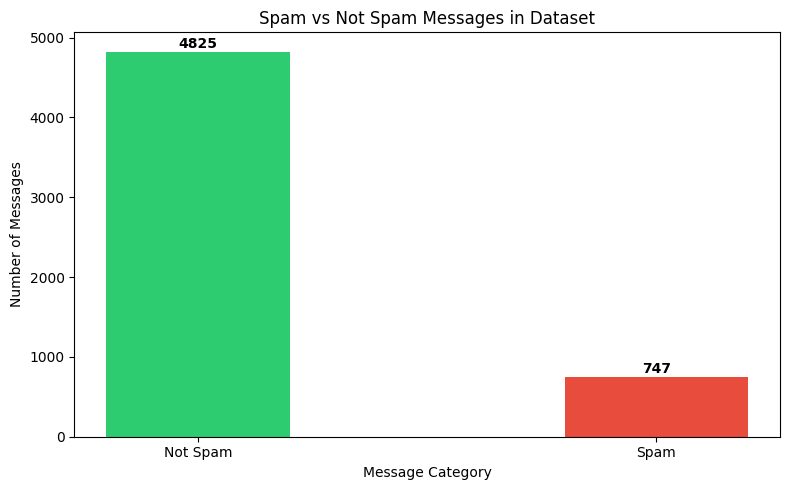

Visualization created successfully! ✅


In [8]:
# Step 5: Visualize the results
labels = ['Not Spam', 'Spam']
counts = [len(df[df['label']=='ham']), len(df[df['label']=='spam'])]
colors = ['#2ecc71', '#e74c3c']

plt.figure(figsize=(8, 5))
plt.bar(labels, counts, color=colors, width=0.4)
plt.title('Spam vs Not Spam Messages in Dataset')
plt.xlabel('Message Category')
plt.ylabel('Number of Messages')
for i, count in enumerate(counts):
    plt.text(i, count + 50, str(count), ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

print("Visualization created successfully! ✅")

In [10]:
# Step 6: Predict new messages
def predict_message(message_text):
    message_vectorized = vectorizer.transform([message_text])
    prediction = model.predict(message_vectorized)
    probability = model.predict_proba(message_vectorized)

    if prediction[0] == 1:
        print("Message:", message_text)
        print("Result: SPAM -", round(probability[0][1]*100, 1), "% confidence")
    else:
        print("Message:", message_text)
        print("Result: NOT SPAM -", round(probability[0][0]*100, 1), "% confidence")
    print("-" * 60)

# Test with new messages
print("TESTING NEW MESSAGES:")
print("=" * 60)
predict_message("Win a free iPhone click here now")
predict_message("Meeting tomorrow at 10am")
predict_message("Congratulations you won 1 million dollars")
predict_message("Can we reschedule our call to Friday")
predict_message("Free entry win amazing prizes click now")
predict_message("Please submit your assignment by Monday")

TESTING NEW MESSAGES:
Message: Win a free iPhone click here now
Result: SPAM - 98.6 % confidence
------------------------------------------------------------
Message: Meeting tomorrow at 10am
Result: NOT SPAM - 99.6 % confidence
------------------------------------------------------------
Message: Congratulations you won 1 million dollars
Result: SPAM - 92.7 % confidence
------------------------------------------------------------
Message: Can we reschedule our call to Friday
Result: NOT SPAM - 97.4 % confidence
------------------------------------------------------------
Message: Free entry win amazing prizes click now
Result: SPAM - 100.0 % confidence
------------------------------------------------------------
Message: Please submit your assignment by Monday
Result: NOT SPAM - 91.3 % confidence
------------------------------------------------------------
